# 1、基础入门

## 1.1 基础langgraph, graph api流程

In [1]:
from operator import add
from typing import TypedDict, Annotated

from langgraph.graph import StateGraph, START, END


# graph api风格
# 1、定义状态 , TypedDict 父类，字典状态
class OverAllState(TypedDict):
    # 日志类型还是 list[str], 但更新的方式不是覆盖 而是add追加
    logs: Annotated[list[str], add]
    # 当前运行的位置。当前的集合
    cur_id: str


# 2、定义节点：本质是定义一个执行的流程
# state: OverAllState 输入类型
# -> OverAllState 返回类型
# 当graph 执行到node1 会在日志添加内容，cur_id 拼接上当前id
def node_1(state: OverAllState) -> OverAllState:
    # 获取当前id
    pre_id = state["cur_id"]
    return {
        # 拼接上node1
        "cur_id": pre_id + ", node_1",
        # 日志
        "logs": ["node_1 运行完毕"],
    }


def node_2(state: OverAllState) -> OverAllState:
    # 获取当前id
    pre_id = state["cur_id"]
    return {
        # 拼接上node1
        "cur_id": pre_id + ", node_2",
        # 日志
        "logs": ["node_2 运行完毕"],
    }


# 3、定义边: 边依赖图添加内容
# 3.1 创建图，获取建造者(类似建造者模式)
builder = StateGraph(state_schema=OverAllState)
# 3.2 添加节点
builder.add_node(node_1)
builder.add_node(node_2)
# 3.3 添加边
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)

# 4、获取图
graph = builder.compile()
# 5、运行图
# 需要传入初始的状态
result = graph.invoke({"cur_id": "start"})
print(result)


{'logs': ['node_1 运行完毕', 'node_2 运行完毕'], 'cur_id': 'start, node_1, node_2'}


# 1.2 图结构可视化

复制 graph td的内容到md文档中就可以渲染出图
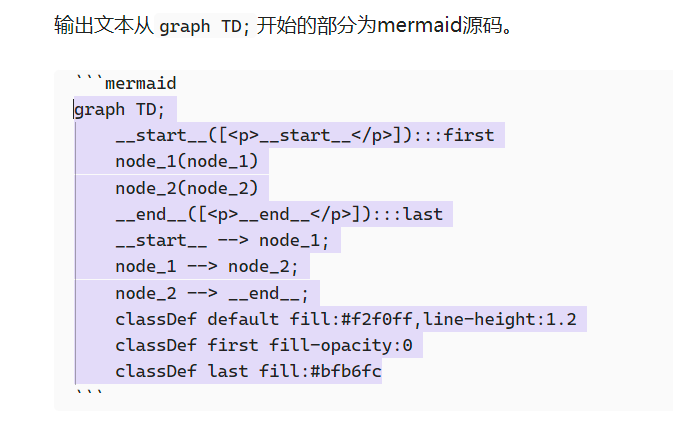
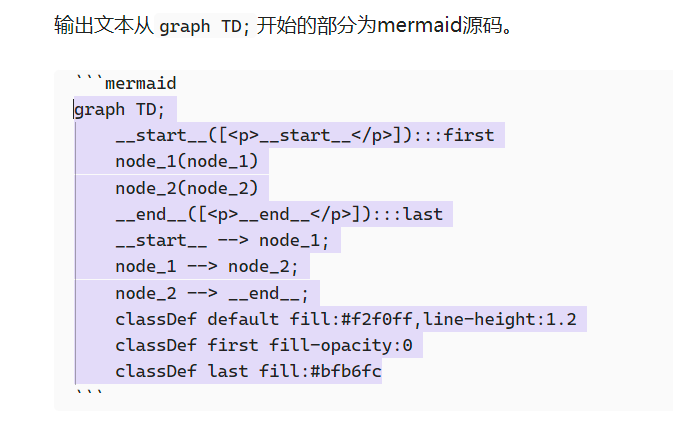

In [2]:
# 获取图的mermaid代码，可以直接在md中渲染
raw_mermaid = graph.get_graph().draw_mermaid()
print(raw_mermaid)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	node_1(node_1)
	node_2(node_2)
	__end__([<p>__end__</p>]):::last
	__start__ --> node_1;
	node_1 --> node_2;
	node_2 --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



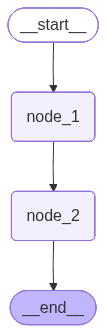

In [3]:
from IPython.display import Image, display

# get_graph 获取图，draw_mermaid_png 获取图mermaid代码
png_bytes = graph.get_graph().draw_mermaid_png()
# 转换为图片
png = Image(png_bytes)
display(png)
